<a href="https://colab.research.google.com/github/leejuheon06/Practice_ML_2/blob/main/02_2_OpenCV_%EA%B8%B0%ED%95%98%ED%95%99%EC%A0%81_%EB%B3%80%ED%99%94_%EC%9D%91%EC%9A%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import urllib.request

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Dejavu Sans' # 기본폰트 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 설정(마이너스 기호 깨짐 방지)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
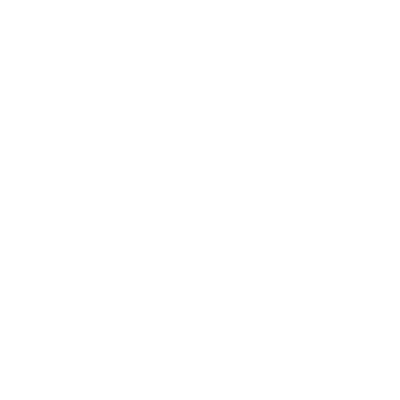

In [4]:
np.ones((400,400,3), dtype=np.uint8) * 255

In [9]:
# 이미지 생성 함수
def create_sample_image():
    # 흰색 배경 이미지 생성 (400*400, 3채널 RGB)
    img = np.ones((400,400,3), dtype=np.uint8) * 255

    # 파란색 사각형 그리기 (왼쪽 위)
    cv2.rectangle(img,          # 그림 이미지
                  (50,50),      # 시작점
                  (150,150),    # 끝점
                  (255, 0, 0),  # BGR (파란색)
                  -1            # 내부 채우기, 양수면 두께
                  )

    # 초록색 원 그리기 (오른쪽 위)
    cv2.circle(img,          # 그림 이미지
                (300,100),    # 중심점
                50,           # 반지
                (0, 255, 0),  # BGR (초록색)
                -1            # 내부 채우기, 양수면 두께
                )

    # 빨간색 삼각형 원 그리기 (아래)
    triangles_pts = np.array([[200,250], [150,350], [250,350]], dtype=np.int32)

    # 세 꼭지점
    cv2.fillPoly(img,
                 [triangles_pts],   # 다각형 점들 (리스트)
                 (0, 0, 255)        # BGR (빨간색)
                 )

    # 텍스트 추가
    cv2.putText(
        img,
        'DoosanRobotics',           # 표시할 텍스트
        (100,250),                  # Text 시작 위치
        cv2.FONT_HERSHEY_SIMPLEX,   # 폰트 종류
        1,                          # 폰트 크기
        (0,0,0),                    # 폰트 색상
        2,                          # 폰트 두께
        cv2.LINE_AA                 # 선 종류 (AA: anti-aliasing 부드러운 선)
    )

    return img  # 생성된 이미지 변환

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
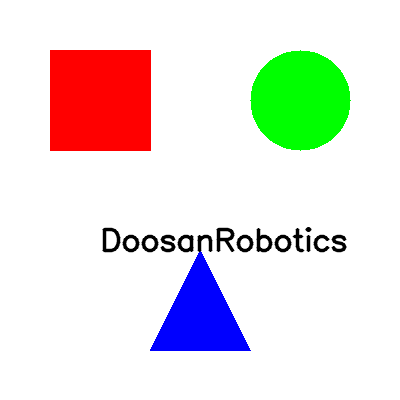

In [11]:
# 이미지 생성
sample_img = create_sample_image()
sample_img

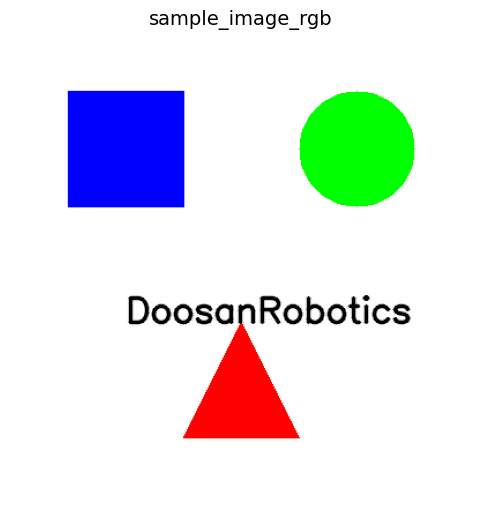

In [12]:
# BGR >> RGB
sample_image = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

# 이미지 표시
plt.figure(figsize=(6,6))
plt.imshow(sample_image)
plt.title('sample_image_rgb', fontsize=14)
plt.axis('off')
plt.show()

In [13]:
sample_image.shape

(400, 400, 3)

필터(Filter) 적용

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
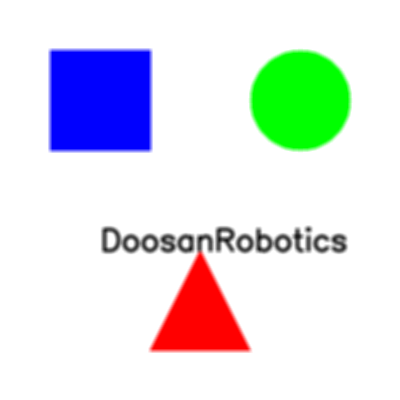

In [15]:
# 평균 블러 (average blur)
# 커널 크기만큼 픽셀들을 평균값으로 대체

cv2.blur(
    sample_image,
    (5,5)           # 커널크기(가로, 세로), 커질수록 더 흐림
)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
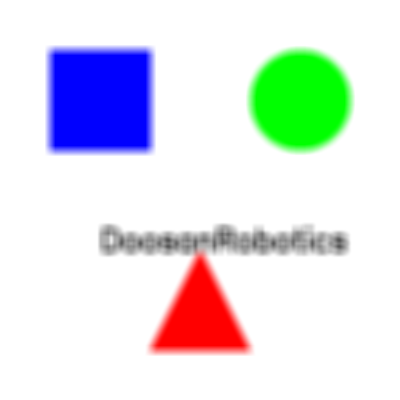

In [16]:
blur_avg = cv2.blur(
    sample_image,
    (11,11)           # 커널크기(가로, 세로), 커질수록 더 흐림
)
blur_avg

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
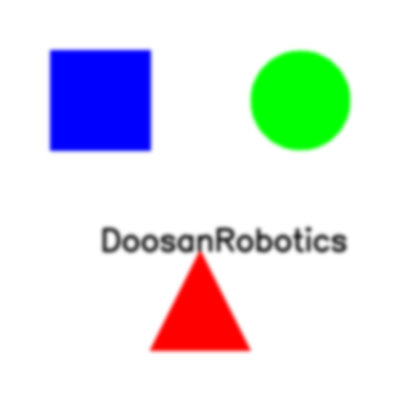

In [17]:
# 가우시안 필터(GaussianBlur)
# 평균, 중심에 가까울 수록 더 큰 가중치(가중평균) 주는 블러

blur_gaussian =cv2.GaussianBlur(
                            sample_image,
                            (11,11),
                            sigmaX=0        # sigmaX(표준편차) 자동 계산
                        )

blur_gaussian

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
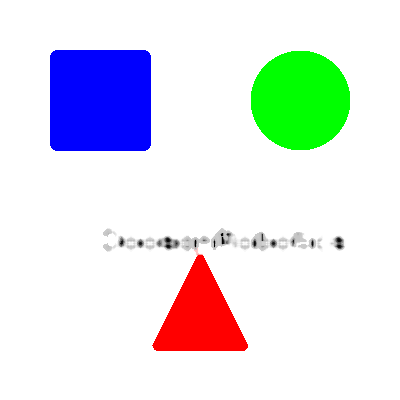

In [18]:
# 중간값 블러(medianBlur)

blur_median = cv2.medianBlur(
                sample_image,
                11         # 반드시 홀수여야 함
)

blur_median

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
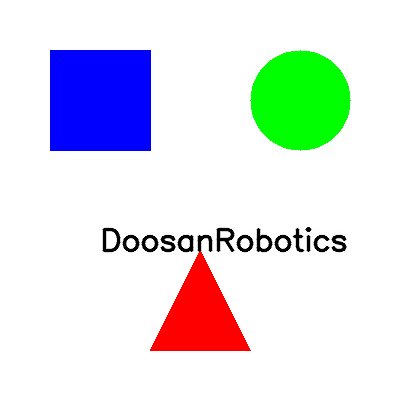

In [21]:
# 양방향 필터(bilateral filter)
# 경계선 보존, 부드럽게 만들어줌 (가장 최고급 필터)

blur_bilateral = cv2.bilateralFilter(
                                sample_image,
                                15,              # 픽셀 이웃 직경
                                80,              # 색상 공간의 표준편차 (클수록 더 많은 색상 표현 가능)
                                80               # 좌표 공간의 표준편차 (클수록 더 넚은 영역 고려)
                            )

blur_bilateral

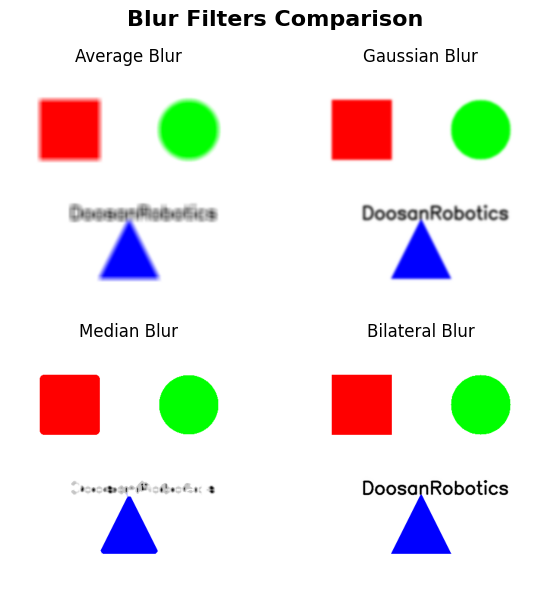

In [23]:
# 4개의 결과를 2*2 그리드로 표시해 보세요
fig, axes = plt.subplots(2,2, figsize=(6,6))
fig.suptitle('Blur Filters Comparison', fontsize=16, fontweight='bold')

images = [blur_avg, blur_gaussian, blur_median, blur_bilateral]
titles = ['Average Blur', 'Gaussian Blur', 'Median Blur', 'Bilateral Blur']

for idx, (ax, img, title) in enumerate(zip(axes.flat, images, titles)):
    # axes.flat : 이미지가 그려질 위치(grid에서)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # BGR >> RGB
    ax.imshow(img_rgb) # 이미지 표시
    ax.set_title(title, fontsize=12) # 제목 설정
    ax.axis('off')     # 축 표 숨기기

plt.tight_layout()
plt.show()

Edge Detection

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
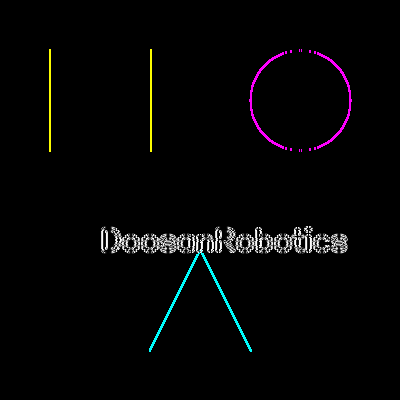

In [25]:
# sobel filter

sobel_x = cv2.Sobel(sample_image,
                    cv2.CV_64F,      # 출력 이미지 타입 지정(64bit float)
                    1,               # x 방향 미분 차수 (1 = 1차 미분) x축 방향 기울기
                    0,               # y 방향 미분 차수 (0 = 미분 안함)
                    ksize=3          # 커널 사이즈 (홀수)
)

# 왼쪽부터 오른쪽 이동, 픽셀값이 변하는 곳 감지 >> 세로 (vertial edge) 강조되는 효과
# 소벨 필터에서 변화가 없는 모든 값은 0(검은색) 예) 255 (현재) - 255(이전) = 0
# >> 변화가 큰 곳은 양수. 검은색>>하얀색 |0-255| = 255
# >> 이미지에서 의미없는 정보(배경)은 0으로 날려버리고, 중요한 정보(윤곽선, 경계) 남기는 필터링
sobel_x = np.uint8(np.absolute(sobel_x))
# 이미지 픽셀은 default(openCV) uint8 (0-255, 256구간)
# 문제는 미분하면 음수 발생 가능 (왜? 255인 흰색이 0인 검은색이 된다? 마이너스 변화)
# 이 문제 때문에 실수인 float 변경했다가 다시 우리가 눈으로 볼 수 있는 unit8로 바꿈
sobel_x

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
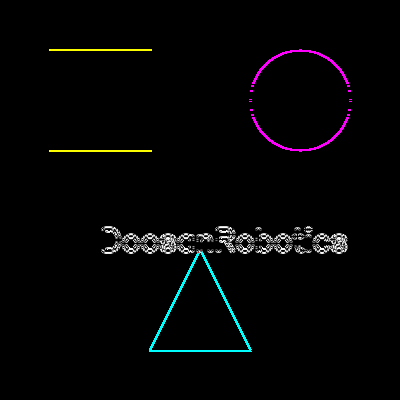

In [26]:
sobel_y = cv2.Sobel(sample_image,
                    cv2.CV_64F,      # 출력 이미지 타입 지정(64bit float)
                    0,               # x 방향 미분 차수 (0 = 미분 안함)
                    1,               # y 방향 미분 차수 (1 = 1차 미분) y축 방향 기울기
                    ksize=3          # 커널 사이즈 (홀수)
)

sobel_y = np.uint8(np.absolute(sobel_y))
# 절대값 취한 뒤, uint8로 변환
sobel_y

array([[[10, 10, 10],
        [10, 10, 10],
        [10, 10, 10],
        ...,
        [10, 10, 10],
        [10, 10, 10],
        [10, 10, 10]],

       [[10, 10, 10],
        [10, 10, 10],
        [10, 10, 10],
        ...,
        [10, 10, 10],
        [10, 10, 10],
        [10, 10, 10]],

       [[10, 10, 10],
        [10, 10, 10],
        [10, 10, 10],
        ...,
        [10, 10, 10],
        [10, 10, 10],
        [10, 10, 10]],

       ...,

       [[10, 10, 10],
        [10, 10, 10],
        [10, 10, 10],
        ...,
        [10, 10, 10],
        [10, 10, 10],
        [10, 10, 10]],

       [[10, 10, 10],
        [10, 10, 10],
        [10, 10, 10],
        ...,
        [10, 10, 10],
        [10, 10, 10],
        [10, 10, 10]],

       [[10, 10, 10],
        [10, 10, 10],
        [10, 10, 10],
        ...,
        [10, 10, 10],
        [10, 10, 10],
        [10, 10, 10]]], dtype=uint8)
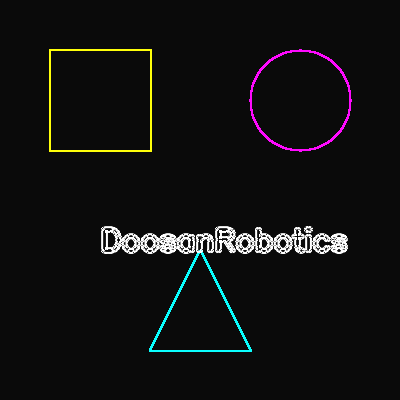

In [27]:
sobel_combined = cv2.addWeighted(sobel_x, 1,  # 1번째 이미지와 가중치
                                sobel_y, 1,   # 2번째 이미지와 가중치
                                10)           # 추가 상수(이미지 밝기 조절)

sobel_combined

# 비추 : 노이즈(noise) 같이 증가 (가중평균시, 0.5 선호 원리: 평균의 원리 추종)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
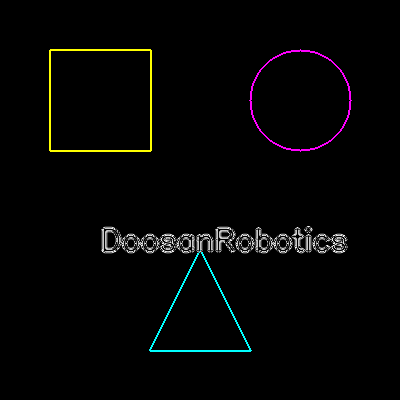

In [29]:
# 라플라시안 필터 (Laplacian Filter)
# 2차 미분(곡률, 변환점) >> 모든 방향 엣지 검출

laplacian = cv2.Laplacian(
                sample_image,
                cv2.CV_64F # 출력 이미지 타입 지정(64비트 float)
)

laplacian = np.uint8(np.absolute(laplacian))
laplacian

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
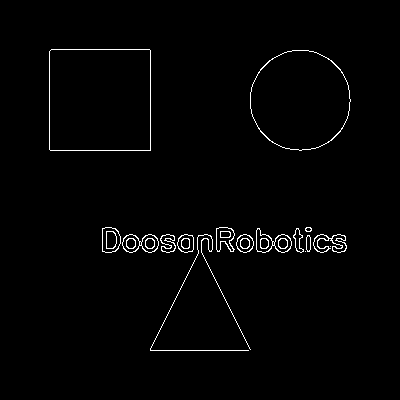

In [31]:
# 캐니 엣지(Canny) : 가장 정밀한 엣지 검출
# 1단계 : grayscale(흑백) 변환
gray = cv2.cvtColor(sample_image, cv2.COLOR_BGR2GRAY)

# 2단계: 엣지 검출 함수 적용
canny = cv2.Canny(gray, # grayscale로 변환된 이미지(캐니는 흑백만 지원)
                50,     # 최소 임계값(threshold) 이보다 낮으면 엣지 아님
                150     # 최대 임계값(이보다 높으면 확신한 엣지)
)

canny

In [32]:
# threshold 자동화
# sigma 편차 개념 : 0.33 (약 1/3 지점 경계로 간주)
def auto_canny(image, sigma=0.33):
    # 픽셀 밝기 median 계산
    v = np.median(image)

    # 중앙값 기준, 하단/상단 임계값(threshold) 설정
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))

    # 결과로 나온 임계값을 canny에 적용
    edge = cv2.Canny(image, lower, upper)

    return edge, lower, upper

Low = 170, High = 255


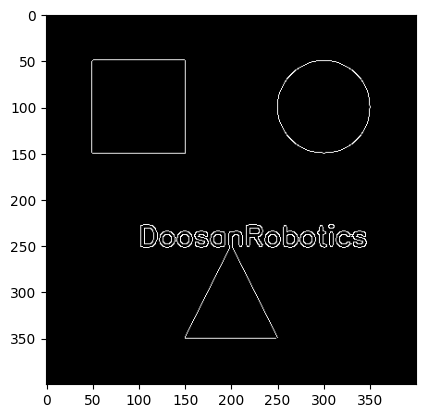

In [33]:
canny_auto, lower, upper  = auto_canny(gray)

print(f'Low = {lower}, High = {upper}')
plt.imshow(canny_auto, cmap='gray')
plt.show()

# 장점: 조명 조건이 다를 경우, 일관된 기준에 의해 엣지 검출 성능 보장
# 단점: 복잡한 배경이 같이 있는 이미지에서는 노이즈가 엣지로 잡힐 수 있음.
# 이럴 경우에는 전처리가 필수 (sigma 값 변경, 가우시안 블러 먼저 적용)

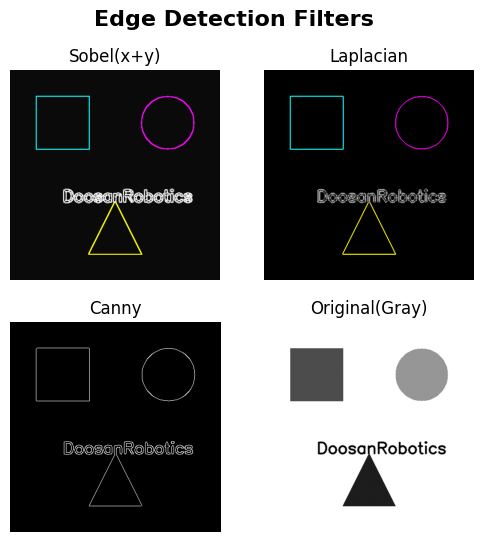

In [34]:
# 4개의 결과를 2*2 그리드로 표시
fig, axes = plt.subplots(2,2,figsize=(6,6))
fig.suptitle('Edge Detection Filters', fontsize=16, fontweight='bold')

# 결과 표시
edge_images = [sobel_combined, laplacian, canny, gray] # 이미지 리스트
edge_titles = ['Sobel(x+y)', 'Laplacian', 'Canny', 'Original(Gray)']

for idx, (ax, img, title) in enumerate(zip(axes.flat, edge_images, edge_titles)):
    # canny와 gray는 이미 흑백 cmap='gray' 사용
    if idx >=2: # canny와 원본 그레이
       ax.imshow(img, cmap='gray') # 흑백 표시
    else:
       img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
       ax.imshow(img_rgb) # 컬러로 표시

    ax.set_title(title, fontsize=12)
    ax.axis('off')

회전/크기 조절

In [41]:
height, width = sample_image.shape[:2]

# 이미지 중심점 계산 (// : 몫)
center = (width//2, height//2)
center

(200, 200)

In [42]:
# 45도 회전
matrix45 = cv2.getRotationMatrix2D(center, # 회전 중심점
                                    45,    # 회전 각도 (양수: 반시계 방향, 음수: 시계 방향)
                                    1.0    # 스케일(1.0 원본 크기 유지)
                                    )

matrix45

array([[  0.70710678,   0.70710678, -82.84271247],
       [ -0.70710678,   0.70710678, 200.        ]])

In [43]:
matrix45.shape

(2, 3)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
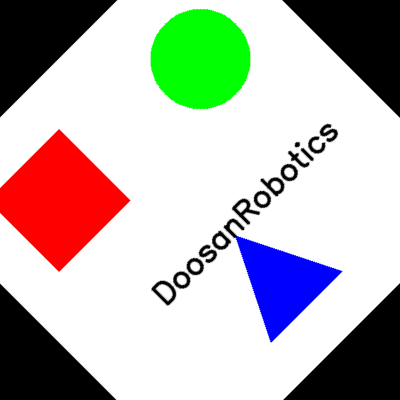

In [44]:
rotated45 = cv2.warpAffine(
    sample_img,     # 원본 이미지
    matrix45,       # 변환 행렬
    (width, height) # 결과 이미지 크기(크기 유지)
)

rotated45

In [45]:
# 90도 회전
matrix90 = cv2.getRotationMatrix2D(center, # 회전 중심점
                                    90,    # 회전 각도 (양수: 반시계 방향, 음수: 시계 방향)
                                    1.0    # 스케일(1.0 원본 크기 유지)
                                    )

matrix90

array([[ 6.12323400e-17,  1.00000000e+00, -2.84217094e-14],
       [-1.00000000e+00,  6.12323400e-17,  4.00000000e+02]])

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
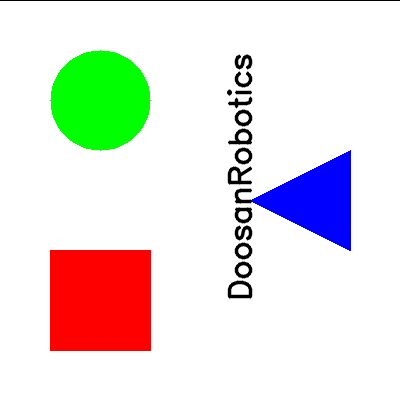

In [46]:
rotated90 = cv2.warpAffine(
    sample_img,     # 원본 이미지
    matrix90,       # 변환 행렬
    (width, height) # 결과 이미지 크기(크기 유지)
)

rotated90

In [47]:
# 45도 회전, 0.5배 축소
matrix45_half = cv2.getRotationMatrix2D(center, # 회전 중심점
                                    45,    # 회전 각도 (양수: 반시계 방향, 음수: 시계 방향)
                                    0.5    # 스케일 0.5
                                    )

matrix45_half

array([[  0.35355339,   0.35355339,  58.57864376],
       [ -0.35355339,   0.35355339, 200.        ]])

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
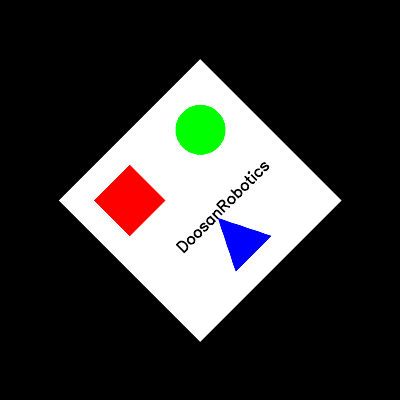

In [49]:
rotated45_half = cv2.warpAffine(
    sample_img,     # 원본 이미지
    matrix45_half,       # 변환 행렬
    (width, height) # 결과 이미지 크기(크기 유지)
)

rotated45_half

In [50]:
# 30회전, 1.5배 확대
matrix30_large = cv2.getRotationMatrix2D(
    center, # 회전 중심점
    30,     # 회전 각도(양수: 반시계방향) 양반음시(양수 반시계 음수 시계)
    1.5     # 스케일
)

matrix30_large

array([[   1.29903811,    0.75      , -209.80762114],
       [  -0.75      ,    1.29903811,   90.19237886]])

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
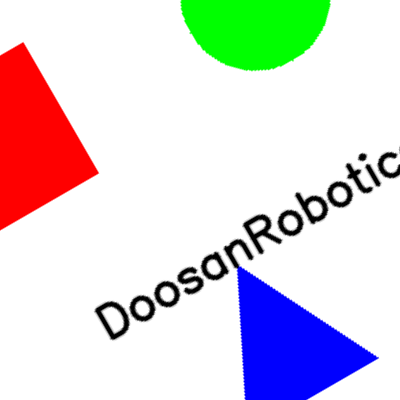

In [51]:
rotated30_large = cv2.warpAffine(
    sample_img,      # 원본이미지
    matrix30_large,        # 변환 행렬
    (width, height)  # 출력 이미지 크기(크기유지)
)

rotated30_large

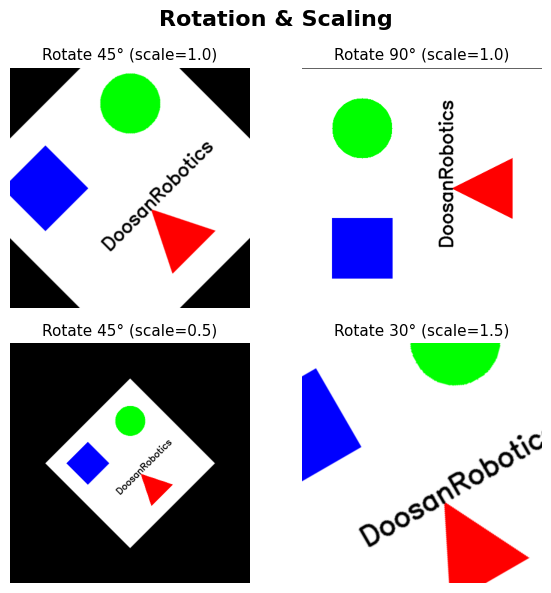

In [53]:
# 결과를 2x2 그리드로 표시
fig, axes = plt.subplots(2, 2, figsize=(6, 6))  # 2행 2열 서브플롯
fig.suptitle('Rotation & Scaling', fontsize=16, fontweight='bold')  # 전체 제목

# 회전 결과들
rotation_images = [rotated45, rotated90, rotated45_half, rotated30_large]  # 이미지 리스트
rotation_titles = [
    'Rotate 45° (scale=1.0)',  # 45도 회전
    'Rotate 90° (scale=1.0)',  # 90도 회전
    'Rotate 45° (scale=0.5)',  # 45도 회전 + 축소
    'Rotate 30° (scale=1.5)'   # 30도 회전 + 확대
]

# 각 subplot에 이미지 표시
for ax, img, title in zip(axes.flat, rotation_images, rotation_titles):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR을 RGB로 변환
    ax.imshow(img_rgb)  # 이미지 표시
    ax.set_title(title, fontsize=11)  # 제목 설정
    ax.axis('off')  # 축 숨기기

plt.tight_layout()  # 레이아웃 자동 조정
plt.show()  # 화면에 표시

보간법(Interpolation)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
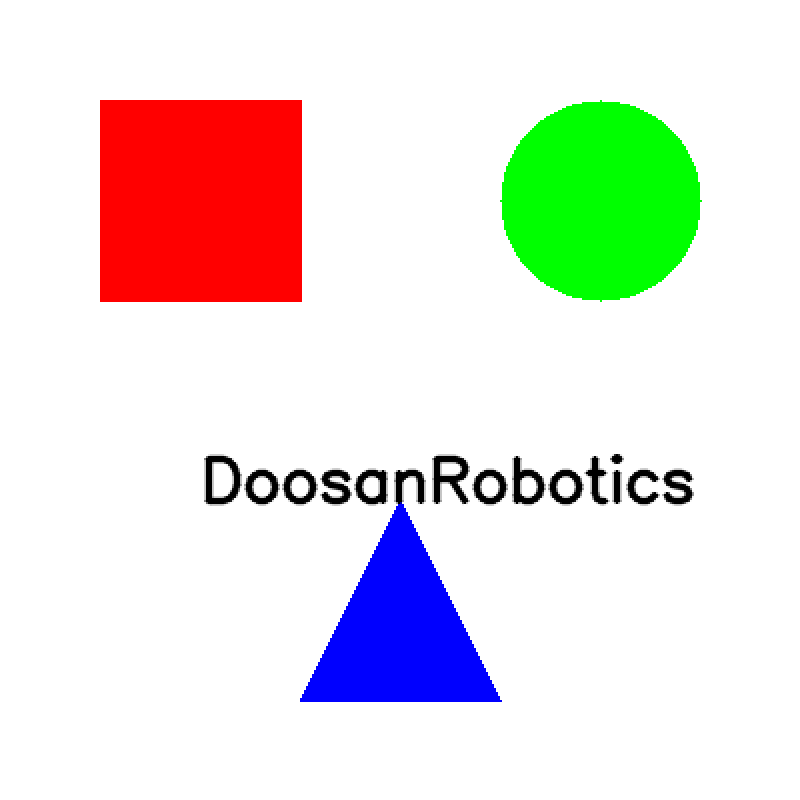

In [58]:
# 원본 이미지를 2배 확대 했을 때

# INTER_NEAREST
# >> 최근접 이웃 셀 값 복사(가장 빠름, 품질 낮음, 계단 현상)
resized_nearest = cv2.resize(
    sample_img,
    (width*2, height*2),
    interpolation=cv2.INTER_NEAREST
)

resized_nearest

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
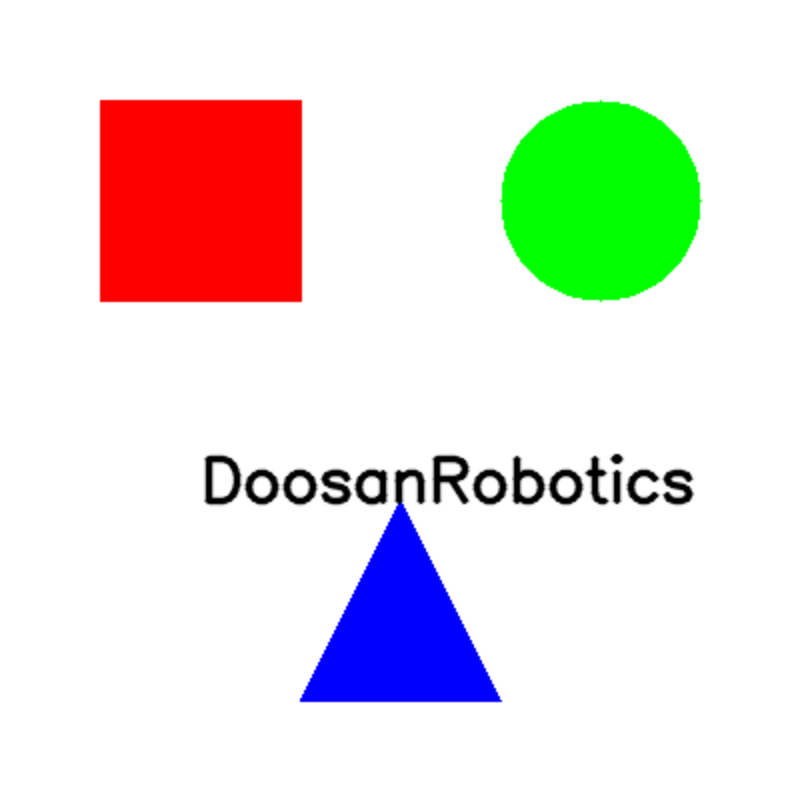

In [59]:
# INTER_LINEAR
# >> 기본값(default), 적당한 속도와 품질
resized_linear = cv2.resize(
    sample_img,
    (width*2, height*2),
    interpolation=cv2.INTER_LINEAR
)

resized_linear

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
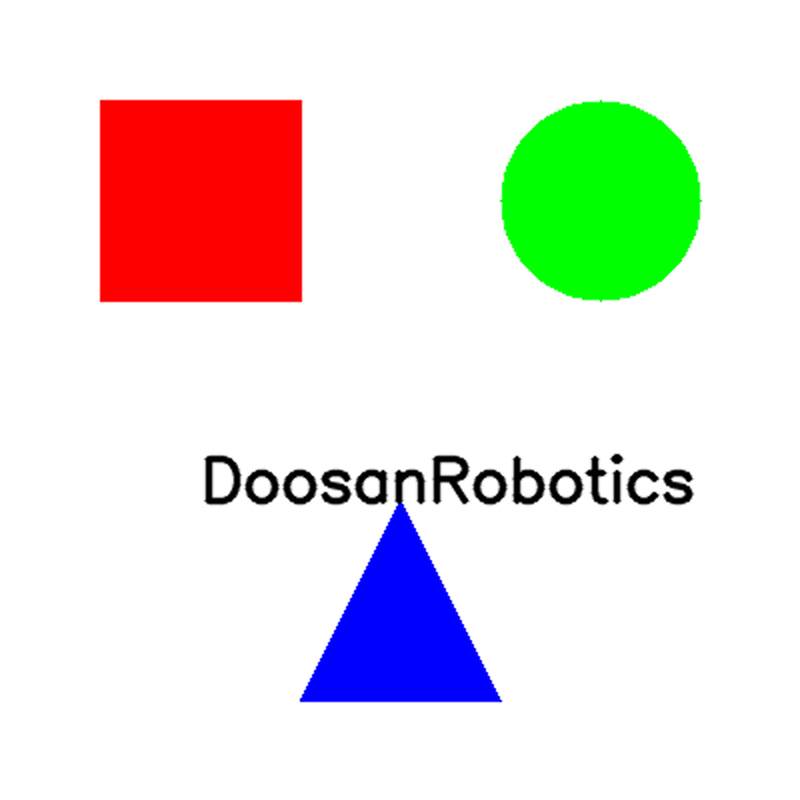

In [60]:
# INTER_CUBIC
# >> 4*4 (고품질), 약간 느림
resized_cubic = cv2.resize(
    sample_img,
    (width*2, height*2),
    interpolation=cv2.INTER_CUBIC
)

resized_cubic

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
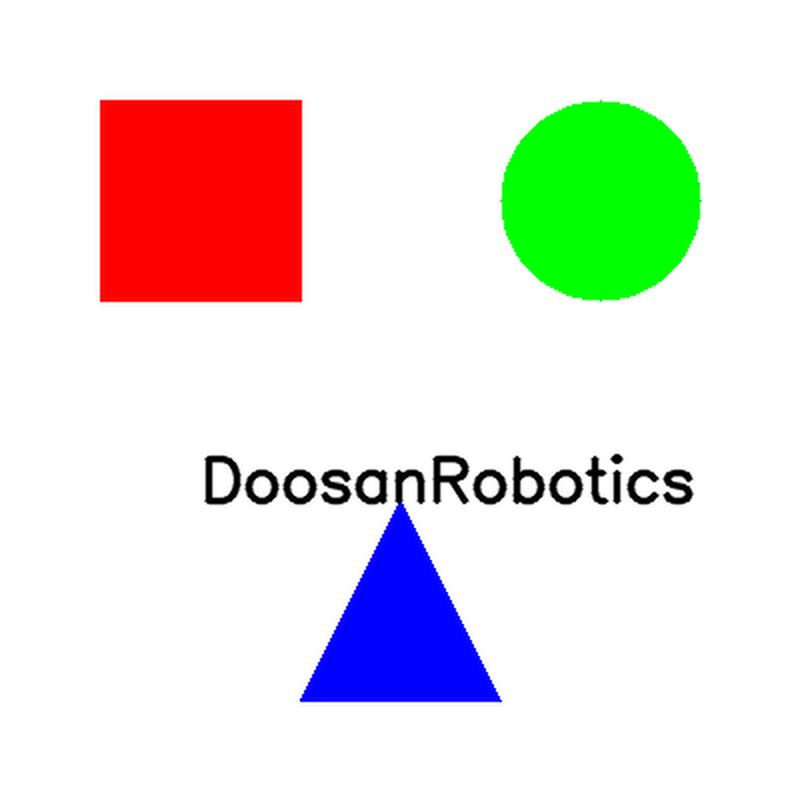

In [62]:
# INTER_LANCZOS
# >> 8*8 (최고품질), 매우 느림
resized_lanczos = cv2.resize(
    sample_img,
    (width*2, height*2),
    interpolation=cv2.INTER_LANCZOS4
)

resized_lanczos

In [63]:
# 각 방법의 일부분을 확대해서 비교 (차이를 명확히 보기 위해)
# 중앙 부근의 80*80 픽셀 영역 추출
crop_y, crop_x = 280, 280  # 자를 위치 (확대된 이미지 기준)
crop_size = 80  # 자를 크기

cropped_nearest = resized_nearest[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]
cropped_linear = resized_linear[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]
cropped_cubic = resized_cubic[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]
cropped_lanczos = resized_lanczos[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]

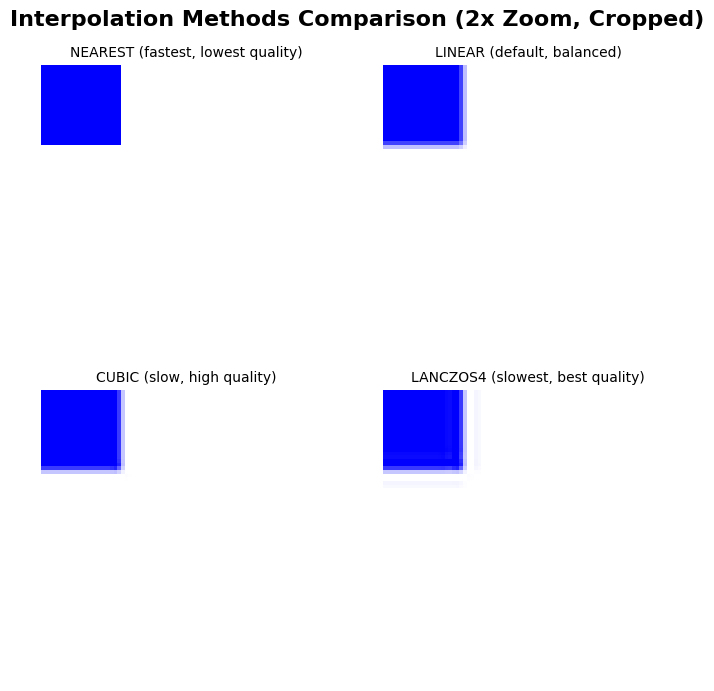

In [66]:
# 결과를 2x2 그리드로 표시
fig, axes = plt.subplots(2, 2, figsize=(7, 7))  # 2행 2열 서브플롯
fig.suptitle('Interpolation Methods Comparison (2x Zoom, Cropped)',
             fontsize=16, fontweight='bold')  # 전체 제목

# 확대 결과들 (일부 영역만)
interp_images = [cropped_nearest, cropped_linear, cropped_cubic, cropped_lanczos]
interp_titles = [
    'NEAREST (fastest, lowest quality)',  # 가장 빠름
    'LINEAR (default, balanced)',  # 기본값
    'CUBIC (slow, high quality)',  # 고품질
    'LANCZOS4 (slowest, best quality)'  # 최고품질
]

# 각 subplot에 이미지 표시
for ax, img, title in zip(axes.flat, interp_images, interp_titles):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR을 RGB로 변환
    ax.imshow(img_rgb)  # 이미지 표시
    ax.set_title(title, fontsize=10)  # 제목 설정
    ax.axis('off')  # 축 숨기기

plt.tight_layout()  # 레이아웃 자동 조정
plt.show()  # 화면에 표시

아핀 변환

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
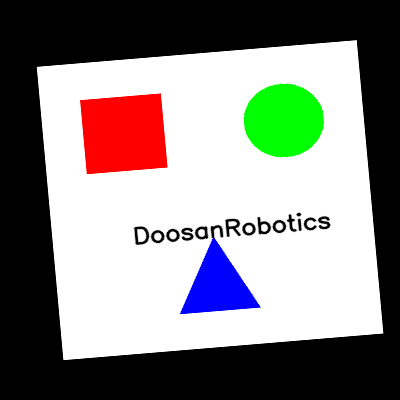

In [67]:
# 3개 점 이용한 변환
src_pts = np.float32([
    [50,50],     # 왼쪽 위 점
    [350, 50],   # 오른쪽 위
    [50, 350]    # 왼쪽 아래 점
])

# 목표 위치 3개 점 지정(변환 후 위치)
dst_pts = np.float32([
    [80,100],   # 첫번째 점 이동 [50,50] >> [80,100] 오른쪽,아래 이동
    [320, 80],  # 두번째 점 이동 [350, 50] >> [320, 80] 왼쪽 아래 이동
    [100, 320]   # 세번째 점 이동 [50, 350] >> [100, 320] 오른쪽 위 이동

])

# 아핀 변환 행렬 계산
affine_matrix = cv2.getAffineTransform(
    src_pts,   # 원본 3개 점
    dst_pts    # 목표 3개 점
)

# 아핀 변환 적용
affine_result = cv2.warpAffine(
    sample_img,
    affine_matrix,
    (width, height)
)

affine_result

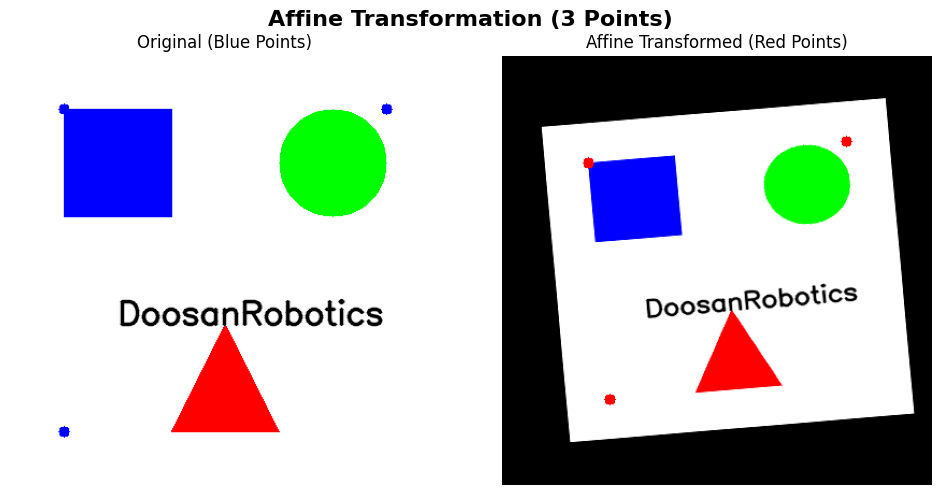

In [69]:
# 원본 이미지에 점표시

original_with_pts = sample_img.copy()

for pt in src_pts:
    cv2.circle(
        original_with_pts,      # 그릴 이미지
        tuple(map(int, pt)),    # 점 위치
        5,                      # 반지름(radius)
        (255,0,0),              # BGR (파란색)
        -1                      # 채우기
    )

# 변환된 이미지에 점 표시
affine_with_pts = affine_result.copy()

for pt in dst_pts:
    cv2.circle(
        affine_with_pts,      # 그릴 이미지
        tuple(map(int, pt)),    # 점 위치
        5,                      # 반지름(radius)
        (0,0,255),              # BGR (빨간색))
        -1                      # 채우기
    )

fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1행 2열 서브플롯
fig.suptitle('Affine Transformation (3 Points)', fontsize=16, fontweight='bold')

# 원본 (파란 점)
axes[0].imshow(cv2.cvtColor(original_with_pts, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original (Blue Points)', fontsize=12)
axes[0].axis('off')

# 변환 결과 (빨간 점)
axes[1].imshow(cv2.cvtColor(affine_with_pts, cv2.COLOR_BGR2RGB))
axes[1].set_title('Affine Transformed (Red Points)', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
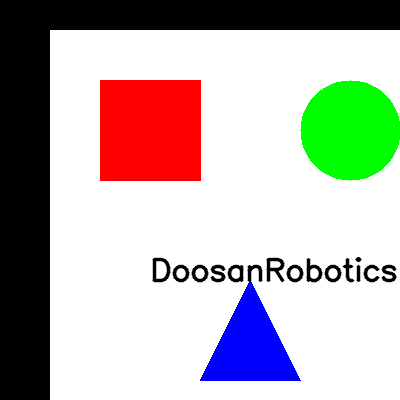

In [70]:
# 수동으로 Affine 변환 행렬 만들기
# 행렬 구조 [[a, b, tx], [c, d, ty]]

# 단순 이동 (transition)
translate_matrix = np.float32([
    [1, 0, 50], # x축: 크기유지, 기울기 없음, 오른쪽 50 px
    [0, 1, 30]  # y축: 크기유지, 기울기 없음, 아래 30 px
    ])

translated = cv2.warpAffine(sample_img, translate_matrix, (width, height))
translated

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[175, 175, 175],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[104, 104, 104],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
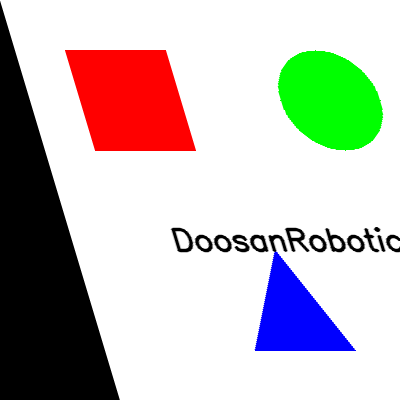

In [71]:
# 수평 기울이기 (Horizontal Shear)
shear_x_matrix = np.float32([
    [1, 0.3, 0], # x축: 변화 없음
    [0, 1, 0]    # y축: 크기 유지, x 값에 따라 y 이동, 이동 없음
    ])

sheared_x = cv2.warpAffine(sample_img, shear_x_matrix, (width, height))
sheared_x

array([[[255, 255, 255],
        [175, 175, 175],
        [104, 104, 104],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
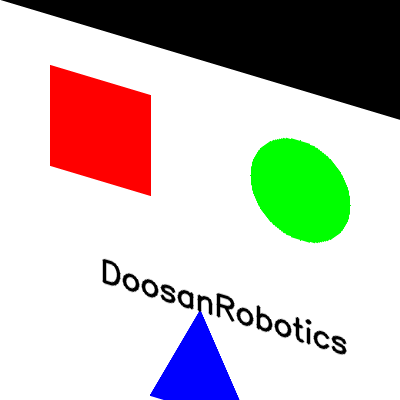

In [72]:
# 수직 기울이기 (Vertical Shear)
shear_y_matrix = np.float32([
    [1, 0, 0],  # x축: 크기 유지, y 값에 따라 x 이동, 이동 없음
    [0.3, 1, 0]   # y축: 변화 없음
    ])

sheared_y = cv2.warpAffine(sample_img, shear_y_matrix, (width, height))
sheared_y

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
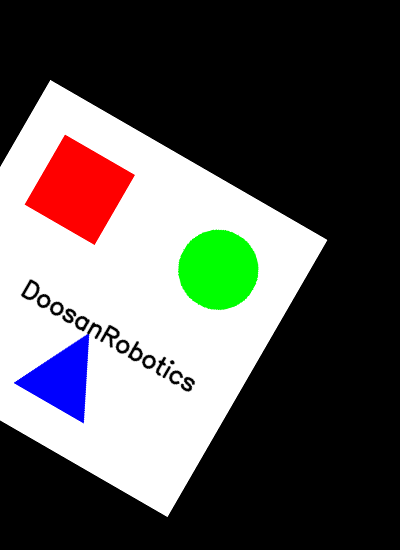

In [73]:
# 복합 변환(회전 + 크기 + 이동)
# cos(30도) 0.866에 근사한 값 가짐, sin(30도) 0.5에 근사한 값 가짐
angle_rad = np.radians(30) # 30도를 radian으로 변환
# np.float64(0.5235987755982988)
cos_val = np.cos(angle_rad) # 코사인 값 계산
sin_val = np.sin(angle_rad) # 사인 값 계산
scale = 0.8   # 0.8배 축소

complex_matrix = np.float32([
    [cos_val * scale, -sin_val * scale, 50], # 회전, 축소, 이동
    [sin_val * scale, cos_val * scale, 80]

])

complex_transformed = cv2.warpAffine(sample_img, complex_matrix, (width, height + 150))
complex_transformed

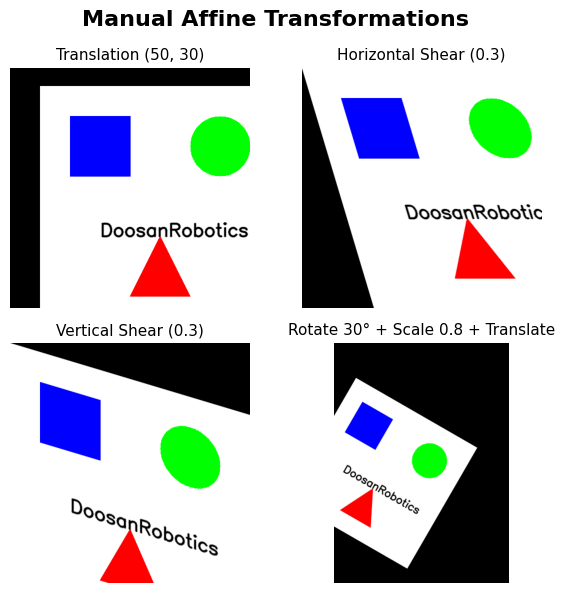

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
fig.suptitle('Manual Affine Transformations', fontsize=16, fontweight='bold')

# 변환 결과들
affine_results = [translated, sheared_x, sheared_y, complex_transformed]
affine_titles = [
    'Translation (50, 30)',  # 이동
    'Horizontal Shear (0.3)',  # 수평 기울임
    'Vertical Shear (0.3)',  # 수직 기울임
    'Rotate 30° + Scale 0.8 + Translate'  # 복합 변환
]

# 각 subplot에 이미지 표시
for ax, img, title in zip(axes.flat, affine_results, affine_titles):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

Perspective 변환

array([[[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       ...,

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]]], dtype=uint8)
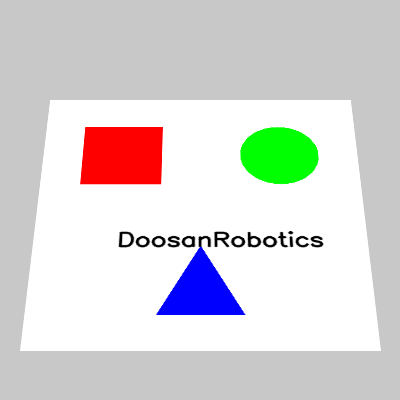

In [75]:
# 4개의 점 활용, 원근 변환
# 비스듬히 찍힌 사진을 정면으로 보정할 때 사용

# 원본 이미지의 4개 꼭지점 (사각형)
src_pts_persp = np.float32([
    [0, 0],           # 왼쪽 위
    [width-1, 0],     # 오른쪽 위
    [width-1, height-1],  # 오른쪽 아래
    [0, height-1]     # 왼쪽 아래
])

# 목표 위치 4개 점 (사다리꼴 모양으로 변환)
dst_pts_persp = np.float32([
    [50, 100],        # 왼쪽 위 → 오른쪽+아래 이동
    [width-50, 100],  # 오른쪽 위 → 왼쪽+아래 이동
    [width-20, height-50],  # 오른쪽 아래 → 왼쪽+위 이동
    [20, height-50]   # 왼쪽 아래 → 오른쪽+위 이동
])
# 결과: 위쪽이 좁고 아래쪽이 넓은 사다리꼴 (원근감)

# perspective 변환 행렬 계산 (3*3 행렬)
perspective_matrix = cv2.getPerspectiveTransform(
    src_pts_persp,  # 원본 4점
    dst_pts_persp   # 목표 4점
    )

# print(perspective_matrix)

perspective_result = cv2.warpPerspective(
    sample_img,
    perspective_matrix, # 3*3 변환 행렬
    (width, height),
    borderValue=(200, 200, 200) # 빈 공간이 있으면 회색으로 채움
)

perspective_result

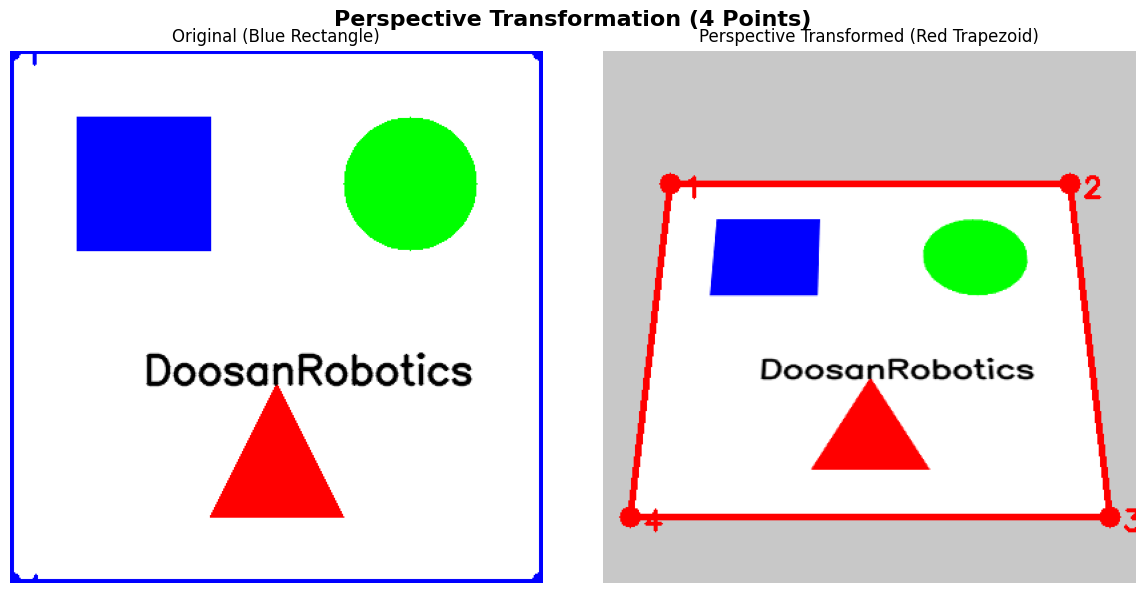

In [77]:
# 시각화: 원본과 목표 점들을 선으로 연결
original_persp = sample_img.copy()
perspective_persp = perspective_result.copy()

# 원본 이미지에 점과 선 그리기
for i, pt in enumerate(src_pts_persp):
    # 점 그리기
    cv2.circle(
        original_persp,
        tuple(pt.astype(int)),
        8,
        (255, 0, 0),  # 파란색
        -1
    )
    # 점 번호 표시
    cv2.putText(
        original_persp,
        str(i+1),
        tuple((pt + [10, 10]).astype(int)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

# 사각형 테두리 그리기
cv2.polylines(
    original_persp,
    [src_pts_persp.astype(int)],  # 점들을 int로 변환
    True,  # 닫힌 도형
    (255, 0, 0),  # 파란색
    3  # 선 두께
)

# 변환된 이미지에 점과 선 그리기
for i, pt in enumerate(dst_pts_persp):
    cv2.circle(
        perspective_persp,
        tuple(pt.astype(int)),
        8,
        (0, 0, 255),  # 빨간색
        -1
    )
    cv2.putText(
        perspective_persp,
        str(i+1),
        tuple((pt + [10, 10]).astype(int)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 0, 255),
        2
    )

cv2.polylines(
    perspective_persp,
    [dst_pts_persp.astype(int)],
    True,
    (0, 0, 255),  # 빨간색
    3
)

# 결과 표시
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Perspective Transformation (4 Points)', fontsize=16, fontweight='bold')

# 원본 (파란색 사각형)
axes[0].imshow(cv2.cvtColor(original_persp, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original (Blue Rectangle)', fontsize=12)
axes[0].axis('off')

# 변환 결과 (빨간색 사다리꼴)
axes[1].imshow(cv2.cvtColor(perspective_persp, cv2.COLOR_BGR2RGB))
axes[1].set_title('Perspective Transformed (Red Trapezoid)', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

실전 예제

array([[[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       ...,

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]],

       [[200, 200, 200],
        [200, 200, 200],
        [200, 200, 200],
        ...,
        [200, 200, 200],
        [200, 200, 200],
        [200, 200, 200]]], dtype=uint8)
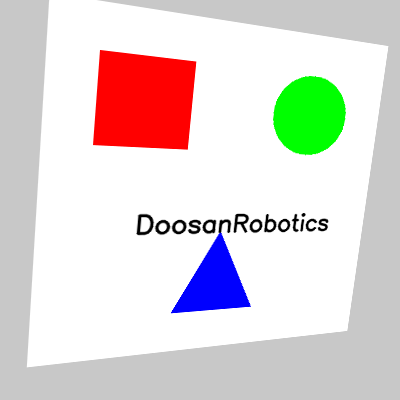

In [79]:
# 비스듬한 문서 >> 정면으로 보정 (문서 스캐너 원리)

# 비스듬한 문서
# 원본(src) 먼저 비스듬하게 만들고 다시 정면으로 복원

# step1 : 정면 >> 비스듬하게 (원근 효과 추가)
src = np.float32([
    [50,50],
    [width-50, 50],
    [width-50, height-50],
    [50, height-50]
])

# 비스듬한 객체 생성
dst_skew = np.float32([
    [100,50],
    [width-50, 80],
    [width-80, height-100],
    [80, height-80]
])

skew_mat = cv2.getPerspectiveTransform(src, dst_skew)
skew_doc = cv2.warpPerspective(sample_img, skew_mat, (width, height), borderValue=(200, 200, 200))
skew_doc

In [80]:
# step2: 비스듬한 객체 >> 복원
# 역변환 위해서는 원본과 목표를 바꿈
correct_mat = cv2.getPerspectiveTransform(dst_skew, src)

correct_doc = cv2.warpPerspective(
    skew_doc,
    correct_mat,
    (width,height),
    borderValue=(255,255,255)
)

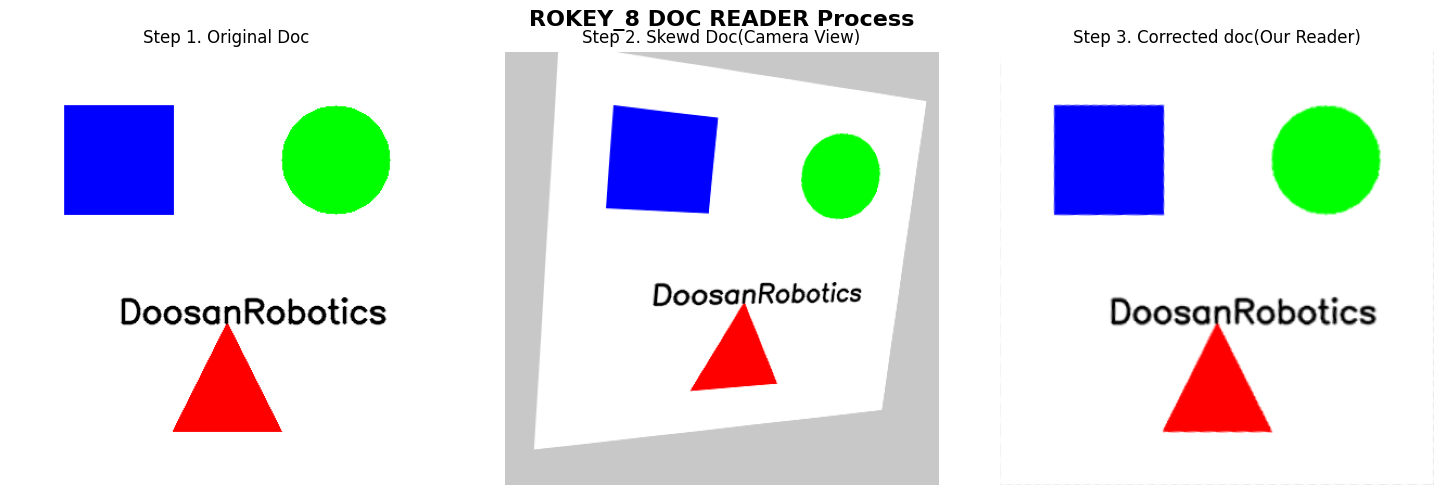

In [83]:
# step 3 : 원본 > 비스듬한 객체 > 보정(복원)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('ROKEY_8 DOC READER Process', fontsize=16, fontweight='bold')

# 원본
axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Step 1. Original Doc', fontsize=12)
axes[0].axis('off')

# 비스듬한 문서
axes[1].imshow(cv2.cvtColor(skew_doc, cv2.COLOR_BGR2RGB))
axes[1].set_title('Step 2. Skewd Doc(Camera View)', fontsize=12)
axes[1].axis('off')

# 우리 리더기를 통한 복원 문서
axes[2].imshow(cv2.cvtColor(correct_doc, cv2.COLOR_BGR2RGB))
axes[2].set_title('Step 3. Corrected doc(Our Reader)', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# eos